The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


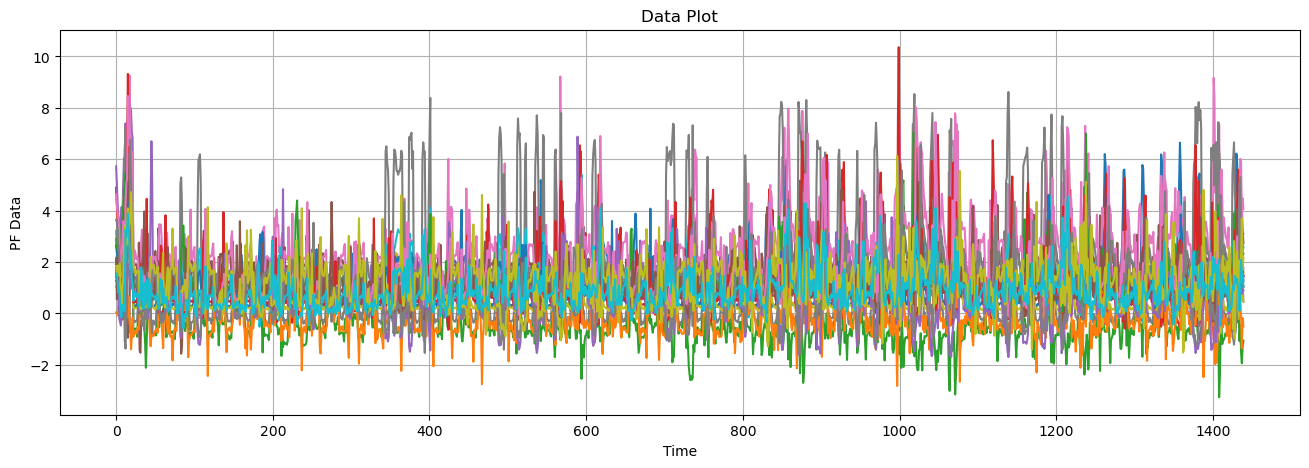

In [13]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import lib.plotGraph as plotGraph
import lib.ioFile as ioFile
import lib.powerfun as powerfun
import lib.graph as graph
import lib.threshold as threshold
import lib.residual as resd
import lib.subBase as subBase
import lib.utils as utils
import lib.ac_se_fdia as ac_se_fdia
from skimage.filters import threshold_li
import pandas as pd
import lib.cycle_space as csp
import tqdm
from scipy.stats import chi2
from lib.read_ac_pf_csv import read_ac_power_flow_data
from scipy.linalg import qr
import pandapower as pp
import pandapower.networks as nw

powerID= 14
IEEENames= ["IEEE 14", "IEEE 30", "IEEE 57", "IEEE 118"]
case_map = {14: nw.case14, 30: nw.case30, 57: nw.case57, 118: nw.case118}
net = case_map[powerID]()
outPutFile= False
# Load MATLAB file
file_name= f'matpower/test_data/DC_case{powerID}_.mat' #14, 118, 57, 30
DC_file= f'data/paper_2/results{powerID}.xlsx' # DC
_, _, H, A, _, _, _, _= ioFile.read_mat_power(file_name, normalize= False)
pfData, _=ioFile.read_excel_power(DC_file, id1= 0, id2= 0)
m= H.shape[0]
n= H.shape[1]
#
param= np.sum(np.abs(H), axis= 1, keepdims= True)/2
m= H.shape[0]
n= H.shape[1]
rankH= n-1
stdOfNoise= 1e-4
numTrain= m+ 1
#
noiseVector= np.random.randn(pfData.shape[0], pfData.shape[1])
noiseE= noiseVector*stdOfNoise
pfDataE= pfData.copy()+noiseE
pfDataTrain= pfData[:m, :]
#
plotTimeSeries= True
if plotTimeSeries:
    plt.figure(figsize=(16, 5))
    for i in range(m):
        plt.plot(pfData[:, i], label=i)
    # plt.yscale("log")
    plt.title('Data Plot')
    plt.xlabel('Time')
    plt.ylabel('PF Data')
    plt.grid(True)
    plt.show()

In [14]:
cycleListTrue= csp.minimum_topology_cycle_basis(A)

In [271]:
#dc power flow cycle basis learning
noiseVector= np.random.randn(pfData.shape[0], pfData.shape[1])
noiseStd= 5e-2
noiseE= noiseVector*noiseStd
print(f"SNR: {utils.calculate_snr(pfData, noiseE):.2f} dB")
pfDataDcNoise= pfData+noiseE
trainData= pfDataDcNoise[:numTrain, :]
testData= pfDataDcNoise[numTrain: 1000, :] 
wholeRight= trainData.T.dot(trainData)
spaningTreeList, leftLinksSet= csp.get_spanning_tree(trainData, rankH, m)
cycleMethod= "old" # "old" or "new"
cycleList, treeLinks, critias= csp.get_cycle_basis(trainData, n, spaningTreeList, method=cycleMethod)
print("tree:", treeLinks)
csp.check_spanning_tree(A, spaningTreeList, rankH)
csp.check_tree_links(A, rankH, treeLinks)
csp.check_cycle_list(A, cycleList, critias, H=H, dataZ=trainData)
#minimumCycleList
residual, cSpaceClean, _= resd.cycle_residual(trainData, rankH, m, testData, cycleList)
print(np.linalg.norm(residual))
residual, cSpaceClean, _= resd.cycle_residual(pfData, rankH, m, testData, cycleListTrue)
print(np.linalg.norm(residual))
#ground truth residual here
NcSpaceClean= cSpaceClean@np.linalg.pinv(cSpaceClean.T@cSpaceClean)@cSpaceClean.T

SNR: 30.35 dB
tree: {13}
spaningTreeList correct: True
treeLinks correct: True
cycleList correct: True
4.680215285572814
4.149312323229296


In [272]:
# statistic test here
noiseStd= 5e-2
csp.compare_cycle_recovery_statistics(pfData, A, rankH, numTrain, noiseStd, numTests=100)

spaningTreeList success rate: 100/100 (100.0%)
Old curvature heuristic:
  treeLinks success rate: 99/100 (99.0%)
  cycleList success rate: 72/100 (72.0%)
New residual-curvature criterion:
  treeLinks success rate: 99/100 (99.0%)
  cycleList success rate: 76/100 (76.0%)


{'spaningTreeList': 1.0,
 'Old curvature heuristic': {'treeLinks': 0.99, 'cycleList': 0.72},
 'New residual-curvature criterion': {'treeLinks': 0.99, 'cycleList': 0.76}}

SNR: 34.61 dB
[4, 17, 13, 6, 7, 16, 5, 15, 12, 18, 0, 14, 9]
spaningTreeList correct: True
treeLinks correct: True
cycleList correct: False
cycleList accuracy: 4/7 (57.1%)
weighted cycleList[0] accuracy: 100.00%
weighted cycleList[1] accuracy: 99.98%
weighted cycleList[2] accuracy: 96.51%
weighted cycleList[3] accuracy: 96.60%
weighted cycleList[4] accuracy: 99.81%
weighted cycleList[5] accuracy: 99.99%
weighted cycleList[6] accuracy: 99.66%
incorrect cycleList[2] links: [3, 4]
incorrect cycleList[3] links: [7, 8]
incorrect cycleList[6] links: [6, 7, 9, 12, 14, 16, 17, 19]


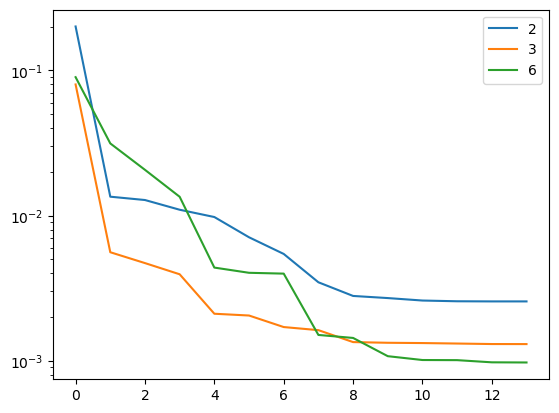

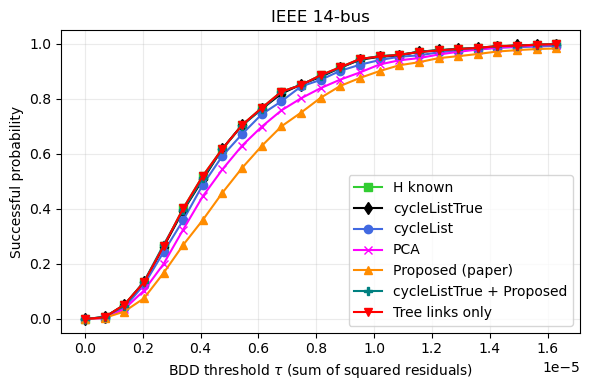

In [429]:
#bentchmark here
benchmarkID= 14
_, _, benchmarkH, benchmarkA, _, _, _, _= ioFile.read_mat_power(f'matpower/test_data/DC_case{benchmarkID}_.mat', normalize=False)
benchmarkData, _= ioFile.read_excel_power(f'data/paper_2/results{benchmarkID}.xlsx', id1=0, id2=0)
benchmarkData= benchmarkData/100 # MW to per unit, as in read_mat_power
benchmarkM, benchmarkN= benchmarkH.shape*1
benchmarkRank, benchmarkMER= benchmarkN-1, 4 if benchmarkID == 14 else 1 # paper Table V: IEEE-14/57
benchmarkTrainCount= benchmarkM*1
benchmarkRng= np.random.default_rng(7)
benchmarkAttackStrength= 8.0
benchmarkProposedRank= benchmarkN- 5
benchmarkCycleAttackRank= benchmarkN- 1
benchmarkNoiseStd= 0.02*np.maximum(np.sqrt(np.mean(benchmarkData[:benchmarkTrainCount]**2, axis=0)), 1e-8)
noisTrain= benchmarkRng.normal(scale=benchmarkNoiseStd, size=(benchmarkTrainCount, benchmarkM))
benchmarkTrain= benchmarkData[:benchmarkTrainCount]+noisTrain
print(f"SNR: {utils.calculate_snr(benchmarkData[:benchmarkTrainCount], noisTrain):.2f} dB")
benchmarkTreeLearned, _= csp.get_spanning_tree(benchmarkTrain, benchmarkRank, benchmarkM)
#true tree here
benchmarkTreeTrue, _= csp.get_spanning_tree(benchmarkA.T, benchmarkRank, benchmarkM)
benchmarkTreeSource= "learned" # switch between "true" and "learned"
benchmarkTree= benchmarkTreeTrue if benchmarkTreeSource == "true" else benchmarkTreeLearned
print(benchmarkTreeLearned)
benchmarkCycleMethod= globals().get("cycleMethod", "old")
benchmarkCycleList, treeLinks, benchmarkCritias= csp.get_cycle_basis(benchmarkTrain, benchmarkN, benchmarkTree, method=benchmarkCycleMethod)
csp.check_spanning_tree(benchmarkA, benchmarkTree, benchmarkRank)
csp.check_tree_links(benchmarkA, benchmarkRank, treeLinks)
csp.check_cycle_list(benchmarkA, benchmarkCycleList, benchmarkCritias, H=benchmarkH, dataZ=benchmarkTrain)
benchmarkTreeLinksTrue= sorted(csp.get_bridge_links(benchmarkA))
benchmarkCycleListTrue= csp.minimum_topology_cycle_basis(benchmarkA)
bddThresholds, successProbability, injectionMagnitude= resd.chi2_attack_success_benchmark(
    benchmarkH, benchmarkTrain, benchmarkData[benchmarkTrainCount:],
    benchmarkCycleListTrue, benchmarkCycleList, benchmarkNoiseStd,
    # attackStrength is the common whitened attack-vector norm
    numTrials=1000, attackStrength=benchmarkAttackStrength, seed=7, paperExtension=benchmarkMER,
    proposedRank=benchmarkProposedRank,
    returnMagnitudes=True, cycleAttackRank=benchmarkCycleAttackRank,
    treeAttackLinks=benchmarkTreeLinksTrue)
styles= [("H known", "limegreen", "s"), ("cycleListTrue", "black", "d"),
         ("cycleList", "royalblue", "o"), ("PCA", "magenta", "x"),
         ("Proposed (paper)", "darkorange", "^"),
         ("cycleListTrue + Proposed", "teal", "P"),
         ("Tree links only", "red", "v")]
plt.figure(figsize=(6, 4))
for name, color, marker in styles:
    plt.plot(bddThresholds, successProbability[name], color=color, marker=marker, label=name)
plt.xlabel(r"BDD threshold $\tau$ (sum of squared residuals)")
plt.ylabel("Successful probability")
plt.title(f"IEEE {benchmarkID}-bus")
# plt.ylim(0, 1.02)
# plt.yscale("log")
# plt.xscale("log")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


In [414]:
# compare subsace accuracy here
# Projection overlap: mean squared cosine of principal angles (1 = exact).
qTrue= np.linalg.svd(benchmarkH, full_matrices=False)[0][:, :benchmarkRank]
proposedRank= benchmarkProposedRank
for name in ["cycleListTrue", "cycleList", "PCA", "Proposed (paper)", "cycleListTrue + Proposed", "Tree links only"]:
    proposed= name == "Proposed (paper)"
    basis= (resd.paper_fdia_basis(benchmarkTrain, benchmarkMER, proposedRank)
            if proposed else injectionMagnitude[name]["rawVector"].T)
    basisRank= proposedRank if proposed else np.linalg.matrix_rank(basis)
    q= np.linalg.svd(basis, full_matrices=False)[0][:, :basisRank]
    overlap= np.linalg.norm(qTrue.T@q, "fro")**2
    accuracy= min(1.0, overlap/min(benchmarkRank, basisRank))
    coverage= min(1.0, overlap/benchmarkRank)
    outside= np.linalg.norm(q-qTrue@(qTrue.T@q), "fro")/np.sqrt(basisRank)
    product= benchmarkH.T@q
    print(f"{name}: accuracy={100*accuracy:.4f}%, coverage={100*coverage:.4f}% (rank {basisRank}), outside Col(H)={outside:.3e}, RMS(H.T@Q)={np.sqrt(np.mean(product**2)):.3e}")

cycleListTrue: accuracy=99.9859%, coverage=99.9859% (rank 29), outside Col(H)=1.189e-02, RMS(H.T@Q)=3.862e+00
cycleList: accuracy=99.3721%, coverage=99.3721% (rank 29), outside Col(H)=7.924e-02, RMS(H.T@Q)=3.830e+00
PCA: accuracy=99.7790%, coverage=99.7790% (rank 29), outside Col(H)=4.701e-02, RMS(H.T@Q)=3.859e+00
Proposed (paper): accuracy=99.8725%, coverage=86.0970% (rank 25), outside Col(H)=3.570e-02, RMS(H.T@Q)=3.798e+00
cycleListTrue + Proposed: accuracy=99.9850%, coverage=86.1940% (rank 25), outside Col(H)=1.225e-02, RMS(H.T@Q)=3.802e+00
Tree links only: accuracy=100.0000%, coverage=10.3448% (rank 3), outside Col(H)=1.658e-15, RMS(H.T@Q)=1.339e+00


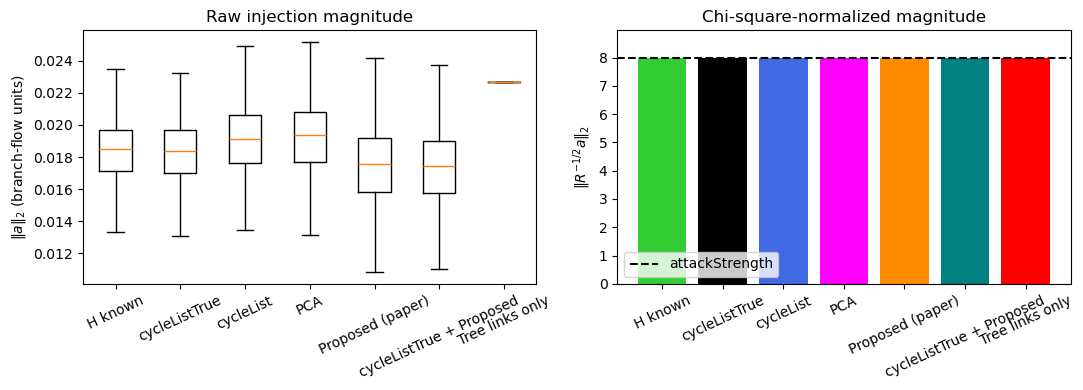

In [405]:
# plot injection magnitude
names= [x[0] for x in styles]
fig, ax= plt.subplots(1, 2, figsize=(11, 4))
ax[0].boxplot([injectionMagnitude[x]["raw"] for x in names], tick_labels=names, showfliers=False)
ax[0].set(title="Raw injection magnitude", ylabel=r"$\|a\|_2$ (branch-flow units)")
ax[1].bar(names, [injectionMagnitude[x]["whitened"].mean() for x in names], color=[x[1] for x in styles])
ax[1].axhline(benchmarkAttackStrength, color="black", linestyle="--", label="attackStrength")
ax[1].set(title="Chi-square-normalized magnitude", ylabel=r"$\|R^{-1/2}a\|_2$", ylim=(0, 1.12*benchmarkAttackStrength))
ax[1].legend()
for a in ax: a.tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()


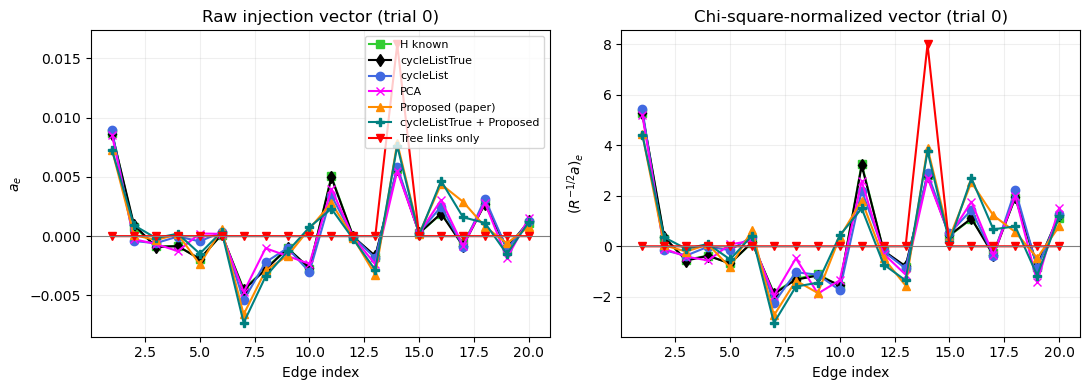

In [384]:
#plot injection vector
edgeIndex= np.arange(1, benchmarkM+1)
fig, ax= plt.subplots(1, 2, figsize=(11, 4), sharex=True)
for name, color, marker in styles:
    ax[0].plot(edgeIndex, injectionMagnitude[name]["rawVector"][0], color=color, marker=marker, label=name)
    ax[1].plot(edgeIndex, injectionMagnitude[name]["whitenedVector"][0], color=color, marker=marker)
ax[0].set(title="Raw injection vector (trial 0)", xlabel="Edge index", ylabel=r"$a_e$")
ax[1].set(title="Chi-square-normalized vector (trial 0)", xlabel="Edge index", ylabel=r"$(R^{-1/2}a)_e$")
for a in ax: a.axhline(0, color="gray", linewidth=.8); a.grid(alpha=.2)
ax[0].legend(fontsize=8)
plt.tight_layout(); plt.show()


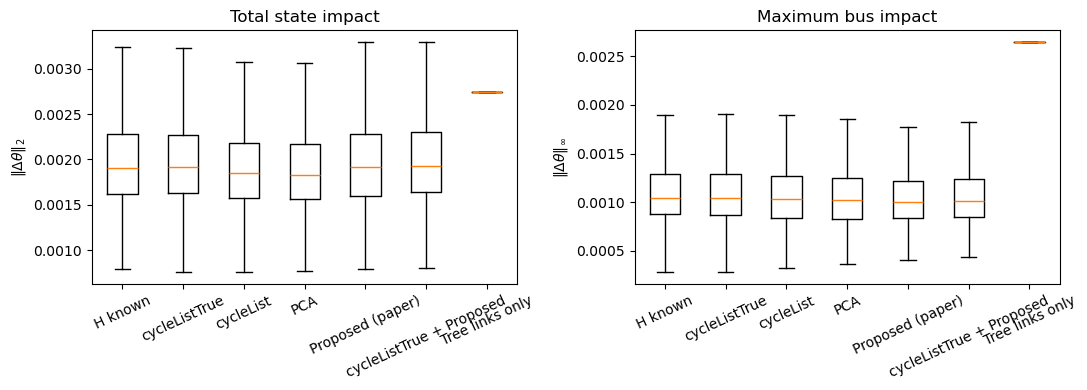

In [385]:
#plot the state impact
fig, ax= plt.subplots(1, 2, figsize=(11, 4))
ax[0].boxplot([injectionMagnitude[x]["stateL2"] for x in names], tick_labels=names, showfliers=False)
ax[0].set(title="Total state impact", ylabel=r"$\|\Delta\theta\|_2$")
ax[1].boxplot([injectionMagnitude[x]["stateMax"] for x in names], tick_labels=names, showfliers=False)
ax[1].set(title="Maximum bus impact", ylabel=r"$\|\Delta\theta\|_\infty$")
for a in ax: a.tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()


num links
20
20
num links


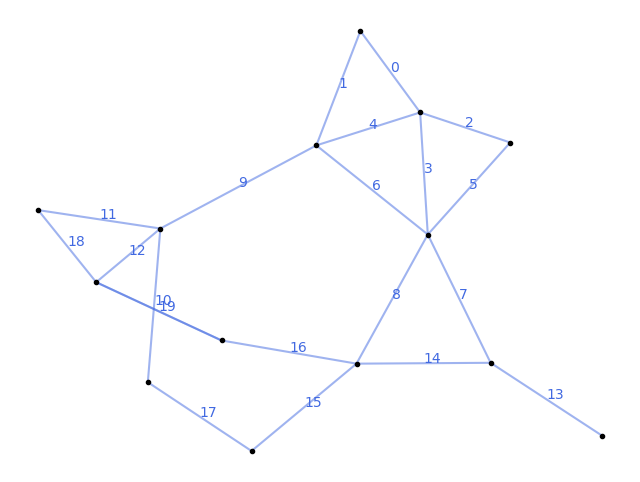

In [386]:
G, node_pair2id= graph.from_A_to_G(A[:, :])
G, _= graph.from_A_to_G(A[:, :])
print("num links")
print(G.number_of_edges())
print(m)
print("num links")
G= G.to_undirected()
biconnected_components = list(nx.biconnected_components(G))
largest_bcc = list(max(biconnected_components, key=len))
plotGraph.plot_spring_layout(G, label= False, label_edge= True, node_pair2id= node_pair2id)